# Sprint 3: SOTA Upgrade (Memory Efficient Pipeline)

Notebook ini mengimplementasikan perbaikan besar-besaran (Sprint 3) untuk menyamakan performa dengan project SOTA MSCNN-BiLSTM-AE.

## Key Improvements:
1. **Preprocessing Baru:** MinMax Scaler (0-1) yang bersih, fit hanya pada Benign Train.
2. **Clipping:** Menangani outlier ekstrim di data Test dengan clipping ke [0, 1].
3. **Memory Efficient:** Menggunakan `tf.data.Dataset` generator untuk streaming data (anti-OOM).
4. **Modular:** Menggunakan script terpisah untuk preprocessing yang konsisten.

In [5]:
# @title Colab Bootstrap (with Drive Persistence)
# Jalankan cell ini jika di Google Colab untuk setup environment
from pathlib import Path
import os
import subprocess
import sys
import shutil

COLAB_BOOTSTRAP_ENABLE = True
COLAB_REPO_URL = "https://github.com/akwancakra/nids-cnn-lstm-autoencoder.git"
COLAB_BRANCH = "feat/sprint3-sota-upgrade"
COLAB_REPO_DIR = Path("/content/nids-cnn-lstm-autoencoder")

# Drive Persistence Config
COLAB_DRIVE_MOUNT = Path("/content/drive")
COLAB_PROJECT_DRIVE_ROOT = COLAB_DRIVE_MOUNT / "MyDrive/nids-cnn-lstm-autoencoder"

def _is_colab_runtime() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False

def _run_shell(cmd: list[str], cwd: Path | None = None) -> None:
    print(f"[CMD] {' '.join(cmd)}")
    subprocess.run(cmd, cwd=str(cwd) if cwd else None, check=True)

def _ensure_symlink_dir(repo_path: Path, drive_target: Path) -> None:
    """Symlink repo folder to drive folder for persistence."""
    drive_target.mkdir(parents=True, exist_ok=True)

    if repo_path.is_symlink():
        if repo_path.resolve() == drive_target.resolve():
            print(f"[INFO] Symlink OK: {repo_path} -> {drive_target}")
            return
        repo_path.unlink()
    elif repo_path.exists():
        if any(repo_path.iterdir()):
            print(f"[WARN] Folder exists and not empty: {repo_path}. Skipping link.")
            return
        repo_path.rmdir()

    repo_path.parent.mkdir(parents=True, exist_ok=True)
    os.symlink(str(drive_target), str(repo_path), target_is_directory=True)
    print(f"[INFO] Symlink created: {repo_path} -> {drive_target}")

if _is_colab_runtime() and COLAB_BOOTSTRAP_ENABLE:
    from google.colab import drive
    drive.mount(str(COLAB_DRIVE_MOUNT))

    if not COLAB_REPO_DIR.exists():
        _run_shell(["git", "clone", "-b", COLAB_BRANCH, COLAB_REPO_URL, str(COLAB_REPO_DIR)])
    else:
        _run_shell(["git", "fetch", "--all"], cwd=COLAB_REPO_DIR)
        _run_shell(["git", "checkout", COLAB_BRANCH], cwd=COLAB_REPO_DIR)
        _run_shell(["git", "pull", "origin", COLAB_BRANCH], cwd=COLAB_REPO_DIR)

    # PERSISTENCE: Link Sprint 3 Data & Models to Drive
    # 1. Processed Data
    _ensure_symlink_dir(
        COLAB_REPO_DIR / "data/research/sprint3_upgrade/processed",
        COLAB_PROJECT_DRIVE_ROOT / "data/research/sprint3_upgrade/processed"
    )
    # 2. Models & Results
    _ensure_symlink_dir(
        COLAB_REPO_DIR / "research/sprint3_upgrade/models",
        COLAB_PROJECT_DRIVE_ROOT / "research/sprint3_upgrade/models"
    )
    _ensure_symlink_dir(
        COLAB_REPO_DIR / "research/sprint3_upgrade/results",
        COLAB_PROJECT_DRIVE_ROOT / "research/sprint3_upgrade/results"
    )

    # Set Working Directory
    os.chdir(COLAB_REPO_DIR)
    print(f"[INFO] Working Directory set to: {os.getcwd()}")
else:
    print("Not in Colab or Bootstrap disabled.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[CMD] git fetch --all
[CMD] git checkout feat/sprint3-sota-upgrade
[CMD] git pull origin feat/sprint3-sota-upgrade
[INFO] Symlink OK: /content/nids-cnn-lstm-autoencoder/data/research/sprint3_upgrade/processed -> /content/drive/MyDrive/nids-cnn-lstm-autoencoder/data/research/sprint3_upgrade/processed
[INFO] Symlink OK: /content/nids-cnn-lstm-autoencoder/research/sprint3_upgrade/models -> /content/drive/MyDrive/nids-cnn-lstm-autoencoder/research/sprint3_upgrade/models
[INFO] Symlink OK: /content/nids-cnn-lstm-autoencoder/research/sprint3_upgrade/results -> /content/drive/MyDrive/nids-cnn-lstm-autoencoder/research/sprint3_upgrade/results
[INFO] Working Directory set to: /content/nids-cnn-lstm-autoencoder


In [6]:
# Setup Project Root & Imports
import os
import sys
from pathlib import Path
import yaml
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import glob
from tqdm.notebook import tqdm

# Deteksi Project Root (Fallback mechanism)
try:
    # Jika di Colab dan sudah chdir, getcwd() adalah root
    PROJECT_ROOT = Path(os.getcwd()).resolve()

    # Validasi sederhana: cek folder research ada atau tidak
    if not (PROJECT_ROOT / "research").exists():
        # Coba naik satu level (jika notebook dijalankan lokal dari folder notebooks/)
        if (PROJECT_ROOT.parent / "research").exists():
            PROJECT_ROOT = PROJECT_ROOT.parent
        else:
            # Fallback hardcoded untuk Colab jika chdir gagal
            PROJECT_ROOT = Path("/content/nids-cnn-lstm-autoencoder")
except Exception:
    PROJECT_ROOT = Path(".")

print(f"Project Root: {PROJECT_ROOT}")
sys.path.append(str(PROJECT_ROOT))

# Load Config Sprint 3
config_path = PROJECT_ROOT / "research/sprint3_upgrade/config/experiment_v1.yaml"

if config_path.exists():
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)
    print(f"Experiment: {config['experiment_name']}")
    print(f"Config Loaded: {config_path}")
else:
    print(f"ERROR: Config not found at {config_path}")
    print("Make sure you have cloned the repo and switched to the correct branch.")

Project Root: /content/nids-cnn-lstm-autoencoder
Experiment: sprint3_sota_upgrade_v1
Config Loaded: /content/nids-cnn-lstm-autoencoder/research/sprint3_upgrade/config/experiment_v1.yaml


## 1. Preprocessing (SOTA Style)
Jalankan script preprocessing baru yang menerapkan MinMax(0-1) dan Clipping.

In [7]:
# Run Preprocessing Script (If data not exists)
processed_dir = PROJECT_ROOT / config['paths']['processed_data']
train_dir = processed_dir / "train"
test_dir = processed_dir / "test"

RUN_PREPROCESSING = False

# --- AUTO DETECT & REUSE LOGIC ---
# Check if processed data already exists (locally or via symlink)
if train_dir.exists() and any(train_dir.iterdir()):
    print("[INFO] Processed data found! Skipping preprocessing.")
    RUN_PREPROCESSING = False

# Adjust Raw Paths for Colab Support
if os.path.exists("/content/drive/MyDrive/nids-data/raw"):
    print("[INFO] Colab Drive Raw Data Detected.")
    raw_train = Path("/content/drive/MyDrive/nids-data/raw/CIC-IDS2017")
    raw_test = Path("/content/drive/MyDrive/nids-data/raw/CSE-CIC-IDS2018")
else:
    # Local fallback or repo path
    raw_train = PROJECT_ROOT / config['paths']['raw_train']
    raw_test = PROJECT_ROOT / config['paths']['raw_test']
# -------------------------------------------------

if RUN_PREPROCESSING:
    print("Running Preprocessing Script... (This may take a while)")
    script_path = PROJECT_ROOT / "research/sprint3_upgrade/scripts/preprocess_sota.py"

    # Check raw data
    if not raw_train.exists():
        print(f"Error: Raw train path {raw_train} not found!")
        print("Please check config or mount drive correctly.")
    else:
        cmd = f'python "{script_path}" --raw_train "{raw_train}" --raw_test "{raw_test}" --output_dir "{processed_dir}" --seq_len {config["preprocessing"]["sequence_length"]} --stride {config["preprocessing"]["stride"]}'
        print(f"Executing: {cmd}")
        !{cmd}
else:
    print("Skipping Preprocessing (Data already exists).")
    print(f"Data Location: {processed_dir}")

[INFO] Processed data found! Skipping preprocessing.
[INFO] Colab Drive Raw Data Detected.
Skipping Preprocessing (Data already exists).
Data Location: /content/nids-cnn-lstm-autoencoder/data/research/sprint3_upgrade/processed


## 2. Data Pipeline (Memory Efficient)
Menggunakan `tf.data.Dataset` generator agar hemat RAM.

In [8]:
# @title 1. Data Pipeline (Flexible: Memory Efficient vs Speed Optimized)
# Pilih mode sesuai kapasitas RAM Colab Anda.

# --- KONFIGURASI MODE ---
PIPELINE_MODE = "SPEED_OPTIMIZED"  # Options: "MEMORY_EFFICIENT" (12GB RAM) or "SPEED_OPTIMIZED" (25GB+ RAM)
# -----------------------

import tensorflow as tf
import glob
import numpy as np
import os

print(f"[INFO] Pipeline Mode: {PIPELINE_MODE}")

def npz_generator(files):
    """
    Generator yang membaca file .npz dari list file satu per satu dan yield batch data.
    """
    if not files:
        # print(f"Warning: No files provided") # Silent warning to avoid spam in logs
        return

    for f in files:
        try:
            with np.load(f, allow_pickle=True) as data:
                # Handle keys
                X = data['X'] if 'X' in data else (data['x'] if 'x' in data else None)

                if X is None:
                    continue

                # Yield per sample (tf.data will batch it later)
                for i in range(len(X)):
                    # Autoencoder: Input = Target (X, X)
                    yield X[i], X[i] # Target is X for AE
        except Exception as e:
            print(f"Error reading {f}: {e}")

def create_dataset(files, batch_size=256, shuffle=True, input_shape=(10, 77)):
    """
    Membuat tf.data.Dataset dari list file shards.
    """
    # Tentukan output signature
    output_signature = (
        tf.TensorSpec(shape=input_shape, dtype=tf.float32), # Input X
        tf.TensorSpec(shape=input_shape, dtype=tf.float32)  # Target X (Autoencoder)
    )

    dataset = tf.data.Dataset.from_generator(
        lambda: npz_generator(files),
        output_signature=output_signature
    )

    # --- LOGIKA MODE ---
    if PIPELINE_MODE == "SPEED_OPTIMIZED":
        # Cache ke RAM setelah pembacaan pertama.
        # Epoch 1: Lambat (Read Disk + Cache). Epoch 2+: Cepat (Read RAM).
        # HATI-HATI: Butuh RAM besar (~20-30GB untuk full dataset)
        dataset = dataset.cache()
        shuffle_buffer = 50000 if shuffle else 1000
    else:
        # Memory Efficient (Streaming)
        # Tidak ada cache, baca disk terus menerus. Hemat RAM tapi lambat.
        shuffle_buffer = 10000 if shuffle else 1000

    if shuffle:
        dataset = dataset.shuffle(buffer_size=shuffle_buffer)

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

# Helper untuk menghitung steps_per_epoch
def count_samples(files):
    total = 0
    if not files:
        print("Warning: No files to count.")
        return 0

    print(f"Counting samples from {len(files)} files...")
    for f in files:
        try:
            with np.load(f, allow_pickle=True) as data:
                key = 'X' if 'X' in data else 'x'
                if key in data:
                    total += data[key].shape[0]
        except: pass
    return total

print("Data Pipeline Ready.")

[INFO] Pipeline Mode: SPEED_OPTIMIZED
Data Pipeline Ready.


## 3. Build & Train Model

Counting samples from 7 files...
Counting samples from 1 files...
Total Train Samples: 1831574
Total Val Samples: 439674


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10, 77)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 10, 32)         │         7,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 5, 16)          │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 5, 64)          │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         5,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 5, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 5, 64)          │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 5, 16)          │         3,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_2 (UpSampling1D)  │ (None, 10, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 10, 77)         │         3,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,445 (243.93 KB)

 Trainable params: 62,445 (243.93 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
7154/7154 ━━━━━━━━━━━━━━━━━━━━ 658s 89ms/step - loss: 0.0134 - val_loss: 0.0031
Epoch 2/50
7154/7154 ━━━━━━━━━━━━━━━━━━━━ 66s 9ms/step - loss: 0.0029 - val_loss: 0.0024
Epoch 3/50
7154/7154 ━━━━━━━━━━━━━━━━━━━━ 66s 9ms/step - loss: 0.0023 - val_loss: 0.0022
Epoch 4/50
7154/7154 ━━━━━━━━━━━━━━━━━━━━ 64s 9ms/step - loss: 0.0021 - val_loss: 0.0021
Epoch 5/50
7154/7154 ━━━━━━━━━━━━━━━━━━━━ 66s 9ms/step - loss: 0.0020 - val_loss: 0.0019
Epoch 6/50
7154/7154 ━━━━━━━━━━━━━━━━━━━━ 66s 9ms/step - loss: 0.0019 - val_loss: 0.0018
Epoch 7/50
7154/7154 ━━━━━━━━━━━━━━━━━━━━ 65s 9ms/step - loss: 0.0018 - val_loss: 0.0018
Epoch 8/50
7154/7154 ━━━━━━━━━━━━━━━━━━━━ 64s 9ms/step - loss: 0.0018 - val_loss: 0.0017
Epoch 9/50
7154/7154 ━━━━━━━━━━━━━━━━━━━━ 64s 9ms/step - loss: 0.0017 - val_loss: 0.0016
Epoch 10/50
7154/7154 ━━━━━━━━━━━━━━━━━━━━ 64s 9ms/step - loss: 0.0017 - val_loss: 0.0016
Epoch 11/50
7154/7154 ━━━━━━━━━━━━━━━━━━━━ 64s 9ms/step - loss: 0.0017 - val_loss: 0.0016
Epoch 12/50
7154/

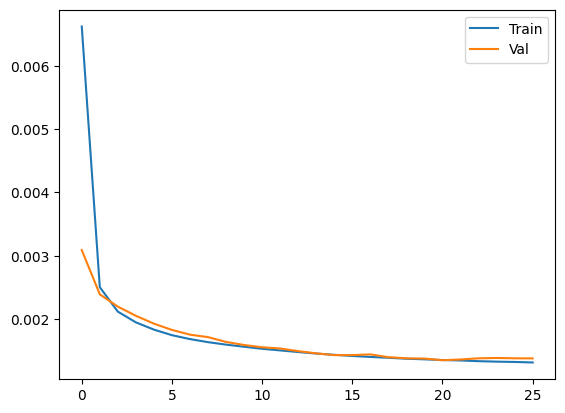

In [9]:
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Concatenate, Bidirectional, LSTM, Dropout, Flatten, Dense, RepeatVector, UpSampling1D
from tensorflow.keras.models import Model

def build_model(input_shape, encoding_dim=16):
    inputs = Input(shape=input_shape)
    # Encoder
    conv1 = Conv1D(32, 3, activation='relu', padding='same')(inputs)
    pool1 = MaxPooling1D(2)(conv1)
    conv2 = Conv1D(16, 3, activation='relu', padding='same')(pool1)
    pool2 = MaxPooling1D(2)(conv2)
    lstm1 = LSTM(64, return_sequences=True)(pool2)
    dropout1 = Dropout(0.2)(lstm1)
    flatten = Flatten()(dropout1)
    encoded = Dense(encoding_dim, activation='relu')(flatten)

    # Decoder
    repeat = RepeatVector(input_shape[0] // 4)(encoded)
    lstm2 = LSTM(64, return_sequences=True)(repeat)
    dropout2 = Dropout(0.2)(lstm2)
    upsample1 = UpSampling1D(2)(dropout2)
    conv3 = Conv1D(16, 3, activation='relu', padding='same')(upsample1)
    upsample2 = UpSampling1D(2)(conv3)
    decoded = Conv1D(input_shape[1], 3, activation='sigmoid', padding='same')(upsample2)
    # Crop to match input length if needed (karena pooling/upsampling bisa merubah dimensi sedikit)
    # Namun dengan input 10 dan pool 2x -> 2, upsample 2x -> 8? Perlu cek shape
    # Input (10, 77) -> Pool1 (5, 32) -> Pool2 (2, 16) -> LSTM (2, 64) -> Flat -> Enc
    # Dec: Repeat(2) -> LSTM (2, 64) -> Up1 (4, 64) -> Conv (4, 16) -> Up2 (8, 16) -> Conv (8, 77)
    # Ada mismatch length (8 vs 10). Kita perlu adjust arsitektur agar simetris.

    # REVISI ARSITEKTUR AGAR MATCH (10, 77)
    # Encoder
    # (10, 77)
    conv1 = Conv1D(32, 3, activation='relu', padding='same')(inputs)
    pool1 = MaxPooling1D(2, padding='same')(conv1) # (5, 32)
    conv2 = Conv1D(16, 3, activation='relu', padding='same')(pool1)
    # Skip pool2 agar tidak ganjil/sulit di upsample balik ke 10
    lstm1 = LSTM(64, return_sequences=True)(conv2) # (5, 64)
    dropout1 = Dropout(0.2)(lstm1)
    flatten = Flatten()(dropout1)
    encoded = Dense(encoding_dim, activation='relu')(flatten)

    # Decoder
    repeat = RepeatVector(5)(encoded) # (5, 16)
    lstm2 = LSTM(64, return_sequences=True)(repeat) # (5, 64)
    dropout2 = Dropout(0.2)(lstm2)
    conv3 = Conv1D(16, 3, activation='relu', padding='same')(dropout2) # (5, 16)
    upsample1 = UpSampling1D(2)(conv3) # (10, 16)
    decoded = Conv1D(input_shape[1], 3, activation='sigmoid', padding='same')(upsample1) # (10, 77)

    autoencoder = Model(inputs, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder

# Setup Training
BATCH_SIZE = config['training']['batch_size']

# 1. Split Files for Train/Val (Supaya Val data tidak bocor & loading cepat)
# Pastikan variabel train_dir sudah terdefinisi dari cell sebelumnya atau load dari config
if 'train_dir' not in locals():
    train_dir = PROJECT_ROOT / config['paths']['processed_data'] / "train"
    test_dir = PROJECT_ROOT / config['paths']['processed_data'] / "test"
    print(f"[INFO] train_dir set to: {train_dir}")

all_files = sorted(glob.glob(str(train_dir / "*.npz")))
split_idx = int(len(all_files) * (1 - config['training']['validation_split']))
train_files = all_files[:split_idx]
val_files = all_files[split_idx:]

train_samples = count_samples(train_files)
val_samples = count_samples(val_files)

print(f"Total Train Samples: {train_samples}")
print(f"Total Val Samples: {val_samples}")

if train_samples > 0:
    # 3. Create Datasets
    train_ds = create_dataset(train_files, batch_size=BATCH_SIZE, shuffle=True)
    val_ds = create_dataset(val_files, batch_size=BATCH_SIZE, shuffle=False)

    # IMPORTANT: Repeat train dataset for infinite epochs
    train_ds = train_ds.repeat()

    train_steps = train_samples // BATCH_SIZE
    val_steps = val_samples // BATCH_SIZE

    # Safety check
    if train_steps == 0: train_steps = 1
    if val_steps == 0: val_steps = 1

    # Build
    input_shape = (10, 77) # Default
    model = build_model(input_shape, encoding_dim=config['model']['encoding_dim'])
    model.summary()

    # Callbacks
    model_save_dir = PROJECT_ROOT / config['paths']['model_save_dir']
    model_save_dir.mkdir(parents=True, exist_ok=True)

    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=config['training']['patience'], restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ModelCheckpoint(str(model_save_dir / "best_model.keras"), save_best_only=True, monitor='val_loss')
    ]

    # Train
    history = model.fit(
        train_ds,
        epochs=config['training']['epochs'],
        steps_per_epoch=train_steps,
        validation_data=val_ds,
        validation_steps=val_steps,
        callbacks=callbacks,
        verbose=1
    )

    # Save Final Model
    model.save(str(model_save_dir / "final_model.keras"))
    print(f"Model saved to {model_save_dir}")

    # Plot
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.legend()
    plt.show()

## 4. Evaluation
Hitung threshold dan evaluasi pada Test Set.

Calculating Threshold...


Val Batches:   0%|          | 0/1717 [00:00<?, ?it/s]

Threshold (P99.0): 0.017348524183034897
Evaluating on Test Set...


Test Batches: 0it [00:00, ?it/s]

Accuracy: 0.8803
Precision: 1.0000
Recall: 0.8803
F1-Score: 0.9363


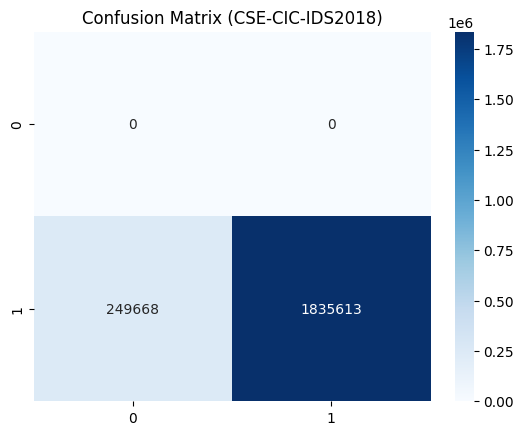

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

# 1. Calculate Threshold
print("Calculating Threshold...")
val_errors = []
for batch_x, _ in tqdm(val_ds, desc="Val Batches", total=val_steps):
    recon = model.predict(batch_x, verbose=0)
    mse = np.mean(np.square(batch_x - recon), axis=(1, 2))
    val_errors.extend(mse)

threshold = np.percentile(val_errors, config['thresholding']['percentile'])
print(f"Threshold (P{config['thresholding']['percentile']}): {threshold}")

# 2. Test Evaluation
print("Evaluating on Test Set...")
def test_gen():
    files = sorted(glob.glob(os.path.join(test_dir, "*.npz")))
    for f in files:
        try:
            with np.load(f, allow_pickle=True) as data:
                X = data['X'] if 'X' in data else (data['x'] if 'x' in data else None)
                y = data['y'] if 'y' in data else (data['Y'] if 'Y' in data else None)
                if X is not None:
                    for i in range(len(X)):
                        yield X[i], y[i]
        except: pass

test_ds = tf.data.Dataset.from_generator(
    test_gen,
    output_signature=(
        tf.TensorSpec(shape=input_shape, dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int32)
    )
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

all_errors = []
all_y = []

for batch_x, batch_y in tqdm(test_ds, desc="Test Batches"):
    recon = model.predict(batch_x, verbose=0)
    mse = np.mean(np.square(batch_x - recon), axis=(1, 2))
    all_errors.extend(mse)
    all_y.extend(batch_y.numpy())

y_pred = (np.array(all_errors) > threshold).astype(int)
y_true = np.array(all_y)

# Metrics
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall: {recall_score(y_true, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_true, y_pred):.4f}")

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (CSE-CIC-IDS2018)')
plt.show()

# --- 3. Additional Evaluation on CIC-IDS2017 (Optional) ---
# Evaluasi pada Test Set CIC-IDS2017 (jika ada) untuk membandingkan performa in-domain vs cross-domain.
cic_test_dir = PROJECT_ROOT / config['paths']['processed_data'] / "test_cic"
if cic_test_dir.exists():
    print("\nEvaluating on CIC-IDS2017 Test Set...")
    def cic_test_gen():
        files = sorted(glob.glob(os.path.join(cic_test_dir, "*.npz")))
        for f in files:
            try:
                with np.load(f, allow_pickle=True) as data:
                    X = data['X'] if 'X' in data else (data['x'] if 'x' in data else None)
                    y = data['y'] if 'y' in data else (data['Y'] if 'Y' in data else None)
                    if X is not None:
                        for i in range(len(X)):
                            yield X[i], y[i]
            except: pass

    cic_ds = tf.data.Dataset.from_generator(
        cic_test_gen,
        output_signature=(
            tf.TensorSpec(shape=input_shape, dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.int32)
        )
    ).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    cic_errors = []
    cic_y = []
    for batch_x, batch_y in tqdm(cic_ds, desc="CIC Test Batches"):
        recon = model.predict(batch_x, verbose=0)
        mse = np.mean(np.square(batch_x - recon), axis=(1, 2))
        cic_errors.extend(mse)
        cic_y.extend(batch_y.numpy())

    y_pred_cic = (np.array(cic_errors) > threshold).astype(int)
    y_true_cic = np.array(cic_y)

    print(f"CIC Accuracy: {accuracy_score(y_true_cic, y_pred_cic):.4f}")
    print(f"CIC Precision: {precision_score(y_true_cic, y_pred_cic):.4f}")
    print(f"CIC Recall: {recall_score(y_true_cic, y_pred_cic):.4f}")
    print(f"CIC F1-Score: {f1_score(y_true_cic, y_pred_cic):.4f}")

    cm_cic = confusion_matrix(y_true_cic, y_pred_cic)
    sns.heatmap(cm_cic, annot=True, fmt='d', cmap='Greens')
    plt.title('Confusion Matrix (CIC-IDS2017)')
    plt.show()